# Correction Oil and gas exercise

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Get the data

Load the data from https://www.kaggle.com/datasets/djzurawski/us-oil-and-gas-production-june-2008-to-june-2018?resource=download and unzip it.

Let’s have a look on the data :
> Note : often, whenn improting data from .csv, you may have issue with special caracters. Here a small checklist with most common issues :
>
> - Delimiters can be `,` or `;` or `tab`,
> - strings may be signaled by double-quote `"`,
> - decimals sign can be `.`, or `,` (or thousands separator), etc.
> - Does the first line contains header or not ?
> - .csv are flatfile, sometimes you can have character encoding issue (especially for files created in Windows environnment : encoding = cp-  vs utf-8
>
> Check the first lines of the file (with the `head` command in a terminal for exemple) to get an idea of the file content and formatting

In [21]:
gas_file = "data/U.S._natural_gas_production.csv"
gas_df = pd.read_csv(gas_file, decimal=",") 

## Overview

Let’s see what the dataframe looks like :

In [22]:
gas_df.head(3)

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
0,2008-06-01,70626,8875,1196,1024,2995,7339,6839,670,1198,540,21446,5241,224,243,3975,323,3989,3576,932
1,2008-07-01,71137,8375,1256,1034,3150,7468,6940,674,1200,512,21547,5256,220,243,4179,324,4008,3834,919
2,2008-08-01,70760,8739,1313,1033,3092,6868,6835,678,1277,529,21777,4896,220,249,4092,327,3896,4056,881


It’s a good habit to look at the `.info()` output :

In [23]:
gas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Month                             121 non-null    object
 1   U.S.                              121 non-null    int64 
 2   Alaska                            121 non-null    int64 
 3   Arkansas                          121 non-null    int64 
 4   Kansas                            121 non-null    int64 
 5   Other States                      121 non-null    int64 
 6   Federal Offshore--Gulf of Mexico  121 non-null    int64 
 7   Wyoming                           121 non-null    int64 
 8   West Virginia                     121 non-null    int64 
 9   Utah                              121 non-null    int64 
 10  Pennsylvania                      121 non-null    int64 
 11  Texas                             121 non-null    int64 
 12  Oklahoma              

We see that the `'Month'` column is an object datatype, not a timestamp datatype, it seems we have to cast it from `string` to `timestamp`, following the YYYY-MM-DD format observed on the `.head()` output :

In [24]:
gas_df['Month'] = pd.to_datetime(gas_df['Month'], format='%Y-%m-%d')
gas_df.head(3)

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
0,2008-06-01,70626,8875,1196,1024,2995,7339,6839,670,1198,540,21446,5241,224,243,3975,323,3989,3576,932
1,2008-07-01,71137,8375,1256,1034,3150,7468,6940,674,1200,512,21547,5256,220,243,4179,324,4008,3834,919
2,2008-08-01,70760,8739,1313,1033,3092,6868,6835,678,1277,529,21777,4896,220,249,4092,327,3896,4056,881


Now, we can address specific dimensions of the timestamp object : year, month… :

In [25]:
gas_df['Month'].dt.year.head()


0    2008
1    2008
2    2008
3    2008
4    2008
Name: Month, dtype: int32

In [26]:
gas_df['Month'].dt.month.head()

0     6
1     7
2     8
3     9
4    10
Name: Month, dtype: int32

### Useful tips and methods

#### Parsing dates

Another and simpler way to load temporal variables directly from the `.csv` file is to give the `'Month'` column to the `parse_dates` argument of the `.read_csv()` method : 

In [28]:
parsed_gas_df = pd.read_csv(gas_file, parse_dates=["Month"], decimal=",")
parsed_gas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Month                             121 non-null    datetime64[ns]
 1   U.S.                              121 non-null    int64         
 2   Alaska                            121 non-null    int64         
 3   Arkansas                          121 non-null    int64         
 4   Kansas                            121 non-null    int64         
 5   Other States                      121 non-null    int64         
 6   Federal Offshore--Gulf of Mexico  121 non-null    int64         
 7   Wyoming                           121 non-null    int64         
 8   West Virginia                     121 non-null    int64         
 9   Utah                              121 non-null    int64         
 10  Pennsylvania                      121 non-null    

#### Code snippets

I present here small code snippets / one-liner that you could - for exemple - use in a `data_overview()` function of your own to produce a quick report about the variables and their quality :

- Count each datatypes :

In [30]:
gas_df.dtypes.value_counts()

int64             19
datetime64[ns]     1
Name: count, dtype: int64

- Missing values :

In [34]:
print(f"Valeurs manquantes : {gas_df.isnull().sum().sum()}")

Valeurs manquantes : 0


- Statistical summary of the numeric variables : 

In [39]:
gas_df.describe().round(1)

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
count,121,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0,121.0
mean,2013-06-01 03:34:12.892561920,82362.4,8836.6,2502.7,797.6,2297.3,4327.6,5867.4,2324.6,1161.2,8309.3,22249.6,5962.7,1738.6,1022.1,3624.9,194.8,5961.1,4484.6,699.9
min,2008-06-01 00:00:00,63984.0,4023.0,1196.0,538.0,1325.0,2100.0,4556.0,657.0,810.0,512.0,19795.0,4812.0,203.0,241.0,3135.0,119.0,2960.0,3576.0,530.0
25%,2010-12-01 00:00:00,75493.0,8309.0,1998.0,702.0,1643.0,3389.0,5290.0,754.0,1054.0,2461.0,21478.0,5241.0,231.0,343.0,3485.0,152.0,4900.0,4348.0,595.0
50%,2013-06-01 00:00:00,81544.0,9135.0,2664.0,805.0,1878.0,3693.0,5613.0,2125.0,1216.0,8217.0,22211.0,5540.0,346.0,933.0,3573.0,172.0,5585.0,4544.0,687.0
75%,2015-12-01 00:00:00,89166.0,9639.0,3088.0,876.0,3078.0,5478.0,6607.0,3701.0,1285.0,13730.0,22940.0,6753.0,3428.0,1642.0,3714.0,236.0,7248.0,4638.0,801.0
max,2018-06-01 00:00:00,99091.0,10262.0,3238.0,1092.0,3520.0,7468.0,7297.0,4820.0,1375.0,16482.0,24681.0,8062.0,6188.0,2333.0,4181.0,330.0,9055.0,5076.0,932.0
std,NaN,8127.9,1095.7,591.6,128.7,754.6,1384.3,816.6,1431.4,164.9,5636.1,1174.2,858.8,1958.2,649.1,217.4,59.6,1474.3,256.9,118.5


Notice how the `.describe()` output for the `'Month'` column may be pointless.

You can also focus on a specific column :

In [40]:
gas_df["U.S."].describe().round(1)

count      121.0
mean     82362.4
std       8127.9
min      63984.0
25%      75493.0
50%      81544.0
75%      89166.0
max      99091.0
Name: U.S., dtype: float64

## Yearly gas production


Data show us the production for each month. The `'Month'` column contains the date of the first day of each month. We want to analyse the yearly production.

### Creating a yearly dataframe

When you want to compute the yearly gas production, you want to sum the monthly gas production grouped by year : thus we apply a `.groupby()` method specifying that we want to groupe years, and the we chain it with the `.sum()` method (aggregation function).

This should remind you what we have done in some SQL request. Remember : a pandas dataframe manipulation has analogies with table manipulation with SQL, it obeys the same logic.

But keep in mind that you can use the `.sum()` method on numerical columns only. You have to pass a `numeric_only=True` argument to `.sum()`.

In [8]:
yearly_gas_df = gas_df.groupby(gas_df['Month'].dt.year).sum(numeric_only=True)
yearly_gas_df.head()

,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
Month,,,,,,,,,,,,,,,,,,,
2008,489473,64732,9395,7229,21678,39112,48393,4709,8726,3759,151483,36206,1617,1773,28518,2262,26289,27351,6240
2009,856876,108986,22353,11689,36078,80346,83413,8692,14782,9009,251694,62535,2919,3040,46867,3463,51221,49716,10071
2010,881622,105219,30475,10708,37542,74309,82687,8718,14361,18771,249632,60074,2568,3741,44101,3068,72873,52259,10521
2011,936163,104154,35384,10191,38187,60213,78095,12948,15170,43014,260747,62075,2592,5155,42315,2615,99905,54215,9181
2012,968632,103856,37571,9714,37045,50102,72988,17694,16079,73950,266989,66337,2772,8473,41846,2197,96895,56037,8092


> Note : another way to manage the numeric-only limitation of the `.sum()` method : we observe that the only column that is non-numeric is precisely the `'Month'` column. It’s a bit counterintuitive, but you can derive a new dataframe by dropping the `'Month'` column, and still ask for grouping records by `'Month'` and use `.sum()` has an aggregation function on those now genuinely numerical columns.


In [9]:
yearly_gas_df = gas_df.drop(columns=['Month']).groupby(gas_df['Month'].dt.year).sum()
yearly_gas_df.head()

,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
Month,,,,,,,,,,,,,,,,,,,
2008,489473,64732,9395,7229,21678,39112,48393,4709,8726,3759,151483,36206,1617,1773,28518,2262,26289,27351,6240
2009,856876,108986,22353,11689,36078,80346,83413,8692,14782,9009,251694,62535,2919,3040,46867,3463,51221,49716,10071
2010,881622,105219,30475,10708,37542,74309,82687,8718,14361,18771,249632,60074,2568,3741,44101,3068,72873,52259,10521
2011,936163,104154,35384,10191,38187,60213,78095,12948,15170,43014,260747,62075,2592,5155,42315,2615,99905,54215,9181
2012,968632,103856,37571,9714,37045,50102,72988,17694,16079,73950,266989,66337,2772,8473,41846,2197,96895,56037,8092


You may notice how the index has been assigned to `'Month'` in this new grouped dataframe. It would be appropriate to rename it to `'Year'`.

Before going ahead, let’s rename the index to `'Year'` : 

In [12]:
# rename the index from Month to Year

yearly_gas_df.index.names = ['Year']
yearly_gas_df.head(1)

,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
Year,,,,,,,,,,,,,,,,,,,
2008,489473,64732,9395,7229,21678,39112,48393,4709,8726,3759,151483,36206,1617,1773,28518,2262,26289,27351,6240


### Cleaner way of dealing with year/month

We could also have created two new and clean columns : a `'year'` column and a `'month'` column, (if you want, it would be good also to rename the previous `'Month'` column `'Date'` (to avoid confusion with `'month'`) :

In [42]:
gas_df["year"] = gas_df["Month"].dt.year
gas_df["month"] = gas_df["Month"].dt.month

In [43]:
gas_df.head(1)

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,...,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California,year,month
0,2008-06-01,70626,8875,1196,1024,2995,7339,6839,670,1198,...,5241,224,243,3975,323,3989,3576,932,2008,6


In [44]:
yearly2_gas_df = gas_df.drop(columns=['Month','year','month']).groupby(gas_df['year']).sum()
yearly2_gas_df.head()

,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
year,,,,,,,,,,,,,,,,,,,
2008,489473,64732,9395,7229,21678,39112,48393,4709,8726,3759,151483,36206,1617,1773,28518,2262,26289,27351,6240
2009,856876,108986,22353,11689,36078,80346,83413,8692,14782,9009,251694,62535,2919,3040,46867,3463,51221,49716,10071
2010,881622,105219,30475,10708,37542,74309,82687,8718,14361,18771,249632,60074,2568,3741,44101,3068,72873,52259,10521
2011,936163,104154,35384,10191,38187,60213,78095,12948,15170,43014,260747,62075,2592,5155,42315,2615,99905,54215,9181
2012,968632,103856,37571,9714,37045,50102,72988,17694,16079,73950,266989,66337,2772,8473,41846,2197,96895,56037,8092


It’s not fundamentaly different from the previous method, but it’s a bit cleaner and more readable : each step is clearly indentified, and it’s easier (and readable) to refer to an explicit `'year'` or `'month'` column than to look for `gas_df['Month'].dt.year` each time you need the year of a record.

### First dataviz

Dataviz can help us to figure out what information the data contain.

Let’s quickly draw a dataviz with bar plots (treating years as discrete but ordered categories, we could also draw a lineplot) : 

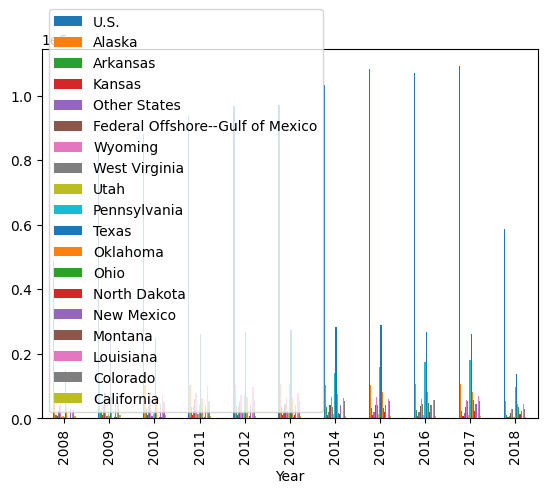

In [13]:
plot = yearly_gas_df.plot(kind="bar")

A bit messy, isn’t it ?
For a first look, let’s focus on the global production of USA only :

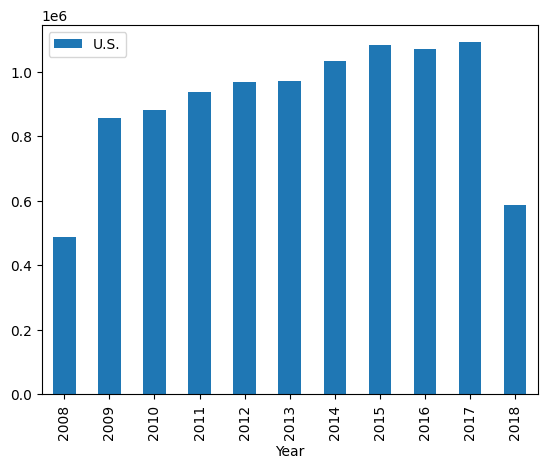

In [14]:
plot = yearly_gas_df.filter(items=['U.S.']).plot(kind="bar")

It appears that the years 2008 and 2018 shows an impaired gas production. Let’s take a look at what the data look like in 2008 and 2018 :

In [15]:
gas_df[gas_df['Month'].dt.year == 2008]

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
0,2008-06-01,70626,8875,1196,1024,2995,7339,6839,670,1198,540,21446,5241,224,243,3975,323,3989,3576,932
1,2008-07-01,71137,8375,1256,1034,3150,7468,6940,674,1200,512,21547,5256,220,243,4179,324,4008,3834,919
2,2008-08-01,70760,8739,1313,1033,3092,6868,6835,678,1277,529,21777,4896,220,249,4092,327,3896,4056,881
3,2008-09-01,63984,9221,1316,1032,2953,2100,6447,657,1276,542,20435,5224,224,260,4069,330,2960,4049,890
4,2008-10-01,69464,9674,1375,1026,3113,4368,6909,692,1241,543,21948,5126,236,267,4168,330,3718,3860,870
5,2008-11-01,71662,9876,1422,1092,3311,5297,7126,681,1275,524,22218,5145,245,269,4078,326,3916,3978,882
6,2008-12-01,71840,9972,1517,988,3064,5672,7297,657,1259,569,22112,5318,248,242,3957,302,3802,3998,866


To get directly the number of lines of the filtered dataframe :

In [19]:
gas_df[gas_df['Month'].dt.year == 2008].shape[0]

7

Same thing for the year 2018 :

In [45]:
gas_df[gas_df['Month'].dt.year == 2018]

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,...,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California,year,month
115,2018-01-01,95418,9573,1670,564,1325,2531,4860,4569,826,...,7332,5911,2072,3662,127,6815,4873,543,2018,1
116,2018-02-01,97225,9593,1665,565,1350,2634,4809,4652,825,...,7513,6110,2095,3791,124,7173,4886,549,2018,2
117,2018-03-01,98278,9542,1646,568,1391,2667,4854,4725,842,...,7763,6161,2114,3976,122,7448,4882,545,2018,3
118,2018-04-01,98618,9424,1712,569,1350,2476,4839,4607,837,...,7836,6134,2245,4037,125,7471,4947,544,2018,4
119,2018-05-01,99091,9121,1661,568,1348,2496,4740,4820,819,...,7867,6188,2333,4008,122,7763,4995,547,2018,5
120,2018-06-01,98428,7634,1637,538,1365,2604,4594,4800,821,...,8062,6187,2301,4181,119,7796,4827,548,2018,6


We can also produce a table with the number of month recorded for each year :

In [52]:
month_by_year = gas_df.groupby("year")["month"].count().rename("month_nb").reset_index() # do not forget the reset_index() : groupby != dataframe
month_by_year

,year,month_nb
0,2008,7
1,2009,12
2,2010,12
3,2011,12
4,2012,12
5,2013,12
6,2014,12
7,2015,12
8,2016,12
9,2017,12


The problem appears clearly : we do not have a complete set of data for 2008 (begins in june) and 2018 (stops in june).
We have three solutions :
- we can group month on june(n-1) / june(n) intervalls (but does this make sense from an economical point of view ?)
- we can simply drop the years 2008 and 2018
- we can use the mean of month production rather than the total production by year (sum)

Let’s keep it simple for this exercise and just filter the incomplete years : we want years above 2008 AND below 2018

>Note (1) : when you use boolean indexing it’s a good practice to define a variable containing your filtering condition, and to apply it on a dataframe in a second time. It has two advantages : it’s more readable, and you can reuse the condition in another part of code.
>For exemple, another way to write the previous boolean indexing code :
>
>```python
>2008_filter = gas_df['Month'].dt.year == 2008
>filtered_df = df[2008_filter]
>```
>
>is a bit more readable than:
>
>```python
>filtered_df = df[gas_df['Month'].dt.year == 2008]
>```
>
>that we have written before (imagine what it would look like with more complex conditions).
>
>Note (2) : a common caveats when you define logical conditions for boolean indexing with dataframe is that pandas refuses the logical operators you may be familiar with (`and`, `or`…) because in an nd-array context they may introduce ambiguity. You have to use bitwise operators : `&`, `|`,… or use the `np.logical_and()`, `np.logical_or()`, … methods which are easier to read and to memorize.
>If you want to learn more about bitwise operators  follow this link : [Python bitwise operator](https://realpython.com/python-bitwise-operators/) (Please note: this involves concepts related to low-level programming)

In [53]:
full_years = np.logical_and(yearly_gas_df.index >= 2009, yearly_gas_df.index <= 2017)
filtered_yearly_gas_df = yearly_gas_df[full_years]

filtered_yearly_gas_df.head()

,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
Year,,,,,,,,,,,,,,,,,,,
2009,856876,108986,22353,11689,36078,80346,83413,8692,14782,9009,251694,62535,2919,3040,46867,3463,51221,49716,10071
2010,881622,105219,30475,10708,37542,74309,82687,8718,14361,18771,249632,60074,2568,3741,44101,3068,72873,52259,10521
2011,936163,104154,35384,10191,38187,60213,78095,12948,15170,43014,260747,62075,2592,5155,42315,2615,99905,54215,9181
2012,968632,103856,37571,9714,37045,50102,72988,17694,16079,73950,266989,66337,2772,8473,41846,2197,96895,56037,8092
2013,970617,105776,37466,9613,22657,43647,67338,24363,15482,107076,272844,65524,5442,11362,41010,2078,77873,52769,8296


Now, let’s draw a clean figure (with a title, axis labels, no useless legend…)

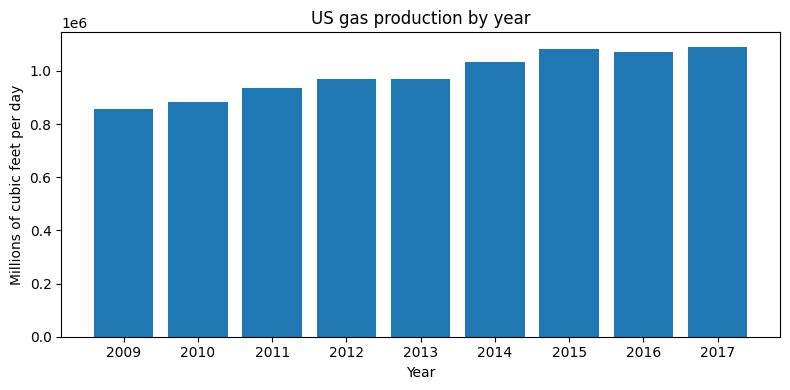

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(filtered_yearly_gas_df.index, filtered_yearly_gas_df['U.S.'].values)
ax.set_xticks(filtered_yearly_gas_df.index)
ax.set_xlabel("Year")
ax.set_ylabel("Millions of cubic feet per day")
ax.set_title("US gas production by year")
plt.tight_layout()
plt.show()

> Repeat using the `.mean()` aggregation function to keep the years 2008 and 2018.

In [59]:
# your code here



## Crude oil comparison

In [60]:
oil_df = pd.read_csv("data/U.S._crude_oil_production.csv", parse_dates=["Month"])

We will not do it in this correction, but at home, redoing this exercise, you should look out for the quality of the oil data as well…

In [63]:
# we have to correct some inconsistency in the states names
oil_df = oil_df.rename(columns={'U.S. Crude Oil ': 'U.S.', 
                                'Federal Offshore Gulf of Mexico Crude Oil': 'Federal Offshore Gulf of Mexico', 
                                'Federal Offshore Pacific Crude Oil': 'Federal Offshore Pacific'})

In [64]:
oil_df["year"] = oil_df["Month"].dt.year
oil_df["month"] = oil_df["Month"].dt.month

Let’s create one dataframe for the US compared production of oil and gas by year :

In [69]:
oil_annual = oil_df.groupby("year")["U.S."].sum() # Reminder unit : Thousands of barrels per day
gas_annual = gas_df.groupby("year")["U.S."].sum() # Reminder unit : Millions of cubic feet per day

annual = pd.DataFrame({"crude_oil": oil_annual, "natural_gas": gas_annual})
annual

,crude_oil,natural_gas
year,,
2008,34211,489473
2009,64180,856876
2010,65741,881622
2011,67829,936163
2012,78007,968632
2013,89585,970617
2014,105064,1032439
2015,113179,1082158
2016,105970,1070085


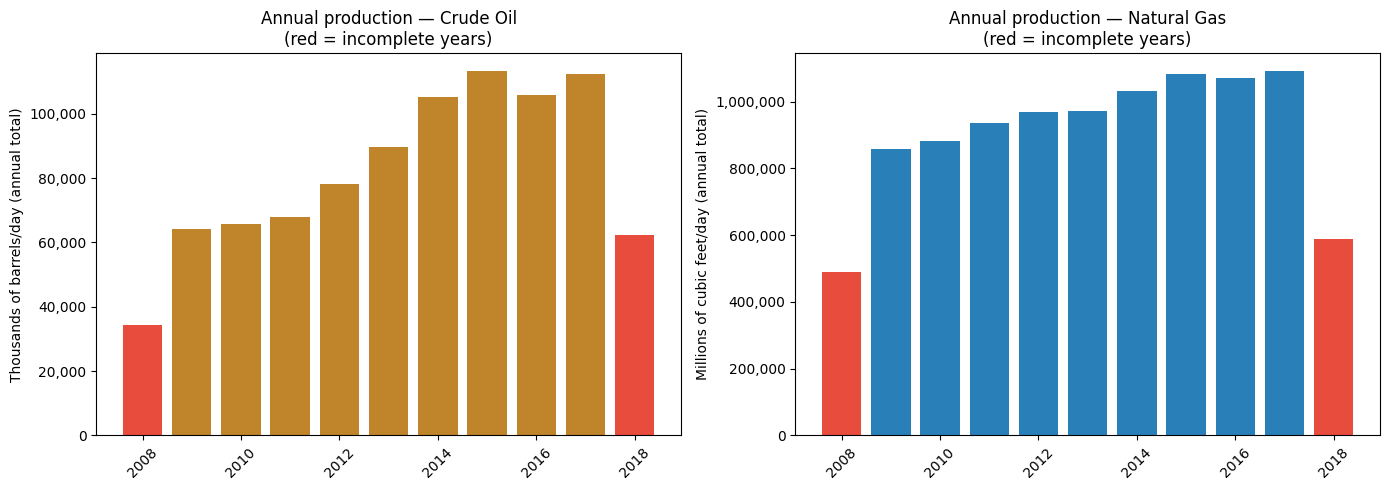

In [74]:
import matplotlib.ticker as mticker # to simplify the code writing for ticker specification

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# this to show you how to create conditional formating :
# we will keep 2008 and 2018 incomplete years but we will color them in red

colors_oil = ["#e74c3c" if y in [2008, 2018] else "#c0842b" for y in oil_annual.index]
colors_gas = ["#e74c3c" if y in [2008, 2018] else "#2980b9" for y in gas_annual.index]

axes[0].bar(oil_annual.index, oil_annual.values, color=colors_oil)
axes[0].set_title("Annual production — Crude Oil\n(red = incomplete years)")
axes[0].set_ylabel("Thousands of barrels/day (annual total)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(gas_annual.index, gas_annual.values, color=colors_gas)
axes[1].set_title("Annual production — Natural Gas\n(red = incomplete years)")
axes[1].set_ylabel("Millions of cubic feet/day (annual total)")
axes[1].tick_params(axis="x", rotation=45)

# to use a coma as thousand separator on y axis
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

## To do :

### State production comparison

1. Sort the states by total production and annual mean production
2. Create a figure : put the states names on the y axis, and production on x axis
3. Show the temporal evolution (monthly) from 2008 to 2018 of the top 5 states (with a line plot). Don’t forget the legend (each state with a different color). Compare oil and gas production of course

### Look out for a seasonality effect

1. Create a figure which shows the average production for each month (what is the average production in january through the years, same for february…). Use a barplot (x : months, y : average production), one figure for oil, a second one for the gas
2. Create a heatmap : draw a table (line : years, columns : months) and apply a palette : the higher the production, the warmer the color

### Oil/gas comparaison

1. To compare two series with different units, we work with base-100 indices (or normalized variation).
    Consider the same beginning date (july 2008), the production of gas, and oil, at this date will be considered 100.
    For each month, compute the evolution of the production compared to this base (oil_index[month] = oil_production[month]/oil_production[base_month] * 100)
    With a plotline, show on the same figure how the oil index and the gas index evolve.
2. Use a scatterplot to show if there is a correlation between oil and gas production. 1 point = 1 month, each year has a specific color (for exemple : all the point for 2008 have the same color, etc.). Has year is an ordered quantity, use a « continuous » palette, like a heatmap palette)

### States comparison (2)
1. Search how to create a pie chart with matplotlib, and use it to show the share of each state in total production (average over the entire period). Aggregate the « small » states in one « others » category to preserve the readability of the chart.
2. Search how to create a area stacked chart with matplotlib. Same instrutions.
3. Compute and show the the average annual growth rate observed for each state. Look for the `.pct_change()` method in [the pandas documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pct_change.html).